# Image Classification on Malaria Cells Dataset - CNN - VGG16 - ResNet50

<img src="https://www.cellavision.com/sites/default/files/media/image/2023-05/MicrosoftTeams-image%20%2866%29.png" alt="Malaria Cell" width="70%">


##### The goal was to classify infected and healthy cells using the Malaria cell images dataset. A CNN model was developed from scratch, and transfer learning techniques were applied using VGG16 and ResNet50 models. The performance of the models was analyzed through visualizations such as accuracy, loss graphs, and confusion matrices.

### Import Libraries

In [ ]:
#pip install opencv-python tensorflow

In [ ]:
import cv2
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Reshape, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Import Data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/cell-images-for-detecting-malaria


In [ ]:
labels=["Parasitized","Uninfected"]
img_path="/kaggle/input/cell-images-for-detecting-malaria/cell_images/"

In [ ]:
img_list=[]
label_list=[]

for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(img_path+label+'/'+img_file)
        label_list.append(label)

In [ ]:
df=pd.DataFrame({"img":img_list,'label':label_list})

### EDA

In [ ]:
df.sample(7)

,img,label
17100,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
26136,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
19823,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
6994,/kaggle/input/cell-images-for-detecting-malari...,Parasitized
27164,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
3408,/kaggle/input/cell-images-for-detecting-malari...,Parasitized
24893,/kaggle/input/cell-images-for-detecting-malari...,Uninfected


In [ ]:
df.shape

(27560, 2)

Bazı img dosyaları bozuk olduğu için o satırları df den siliyoruz - Some image files were corrupted, so the corresponding rows were removed from the DataFrame.

In [ ]:
broken = []
for p in df['img']:
    if cv2.imread(p) is None:
        broken.append(p)

# Ardından df’i temizleyin
df = df[~df['img'].isin(broken)].reset_index(drop=True)

In [ ]:
df.shape

(27558, 2)

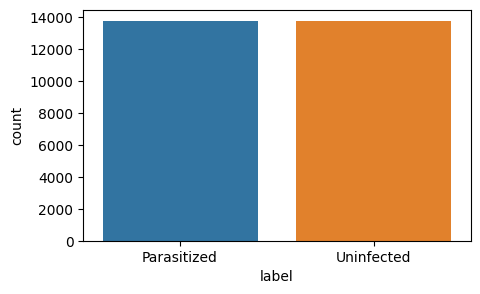

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='label', hue="label");

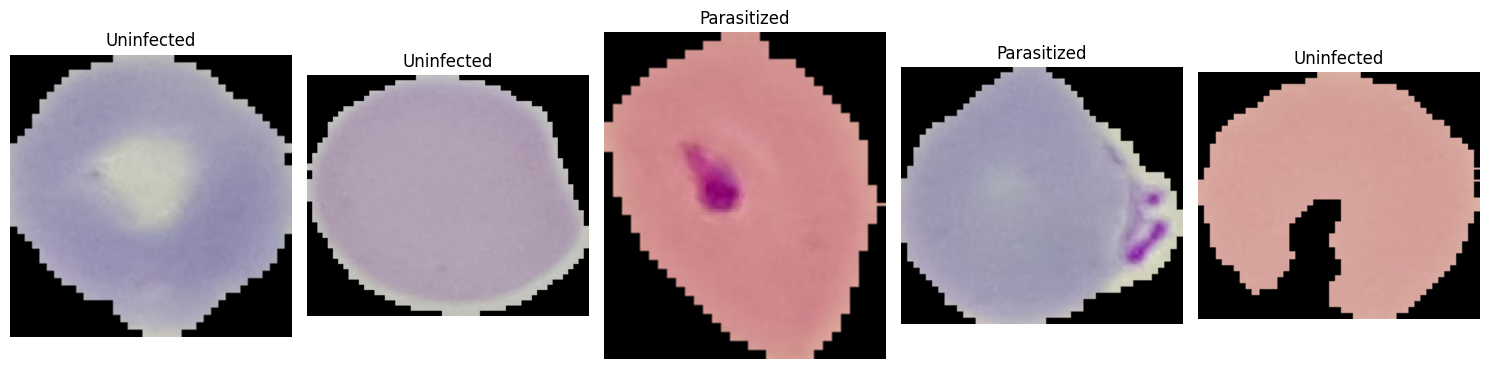

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for ax, (idx, row) in zip(axes, df.sample(5).iterrows()):
    ax.imshow(mpimg.imread(row['img']))
    ax.set_title(row['label'])
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Label Encoding

In [ ]:
d={"Parasitized":1,"Uninfected":0}

In [ ]:
df["encode_label"]=df["label"].map(d)

In [ ]:
df.sample(3)

,img,label,encode_label
3716,/kaggle/input/cell-images-for-detecting-malari...,Parasitized,1
1882,/kaggle/input/cell-images-for-detecting-malari...,Parasitized,1
5472,/kaggle/input/cell-images-for-detecting-malari...,Parasitized,1


### Modelling

In [ ]:
x = []
for img_path in df['img']:
    img = cv2.imread(img_path)
    img = cv2.resize(img, (170,170)).astype('float32')/255.0
    x.append(img)


In [ ]:
x=np.array(x)

In [ ]:
y=df["encode_label"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2, random_state=42, stratify=y)

In [ ]:
# Building the optimized CNN model
model = Sequential([
    Input(shape=(170, 170, 3)),  # Input layer

    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),


    # Instead of Flatten + many Dense layers ➔ GlobalAveragePooling2D
    GlobalAveragePooling2D(),

    # Final Dense layer
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,                # 5 epoch boyunca iyileşme olmazsa durdur
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    x_train, y_train,
    batch_size=64,
    validation_data=(x_test, y_test),
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 698s 2s/step - accuracy: 0.7683 - loss: 0.4944 - val_accuracy: 0.5000 - val_loss: 3.4342
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.9358 - loss: 0.1950 - val_accuracy: 0.8743 - val_loss: 0.3212
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - accuracy: 0.9462 - loss: 0.1678 - val_accuracy: 0.8750 - val_loss: 0.3478
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 678s 2s/step - accuracy: 0.9507 - loss: 0.1507 - val_accuracy: 0.7462 - val_loss: 0.5453
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.9520 - loss: 0.1474 - val_accuracy: 0.6451 - val_loss: 1.3002
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 681s 2s/step - accuracy: 0.9527 - loss: 0.1457 - val_accuracy: 0.9503 - val_loss: 0.1419
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 678s 2s/step - accuracy: 0.9513 - loss: 0.1440 - val_accuracy: 0.9468 - val_loss: 0.1523
Epoch 8/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 679s 2s/step - accuracy: 0.9580 - loss: 0.1310 - val_accu

In [ ]:
model.save("my_cnn_model.keras")

In [ ]:
# Evaluating the model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

173/173 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.9608 - loss: 0.1180
Test Loss: 0.1147
Test Accuracy: 0.9606


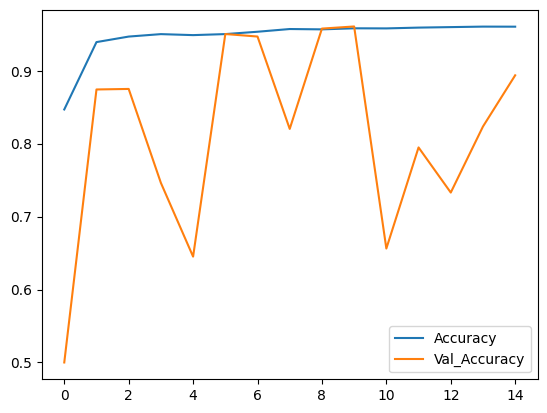

In [ ]:
plt.plot(history.history["accuracy"], label="Accuracy")
plt.plot(history.history["val_accuracy"], label="Val_Accuracy")
plt.legend()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 170, 170, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 170, 170, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 170, 170, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 170, 170, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 85, 85, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 85, 85, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 85, 85, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 85, 85, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,976 (874.91 KB)

 Trainable params: 74,530 (291.13 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 149,062 (582.28 KB)

173/173 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step


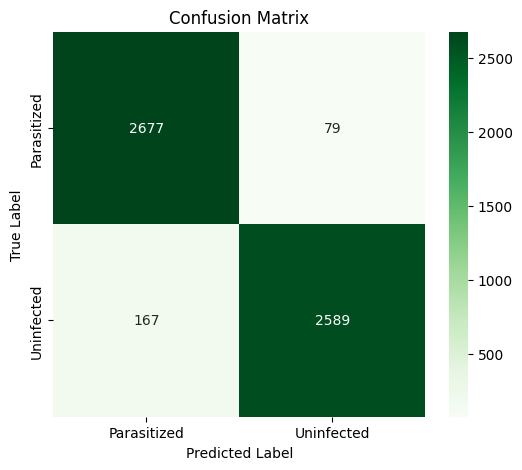

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.94      0.97      0.96      2756
  Uninfected       0.97      0.94      0.95      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



In [116]:
y_pred = model.predict(x_test)
y_pred_classes = y_pred.argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Parasitized", "Uninfected"], yticklabels=["Parasitized", "Uninfected"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=["Parasitized", "Uninfected"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


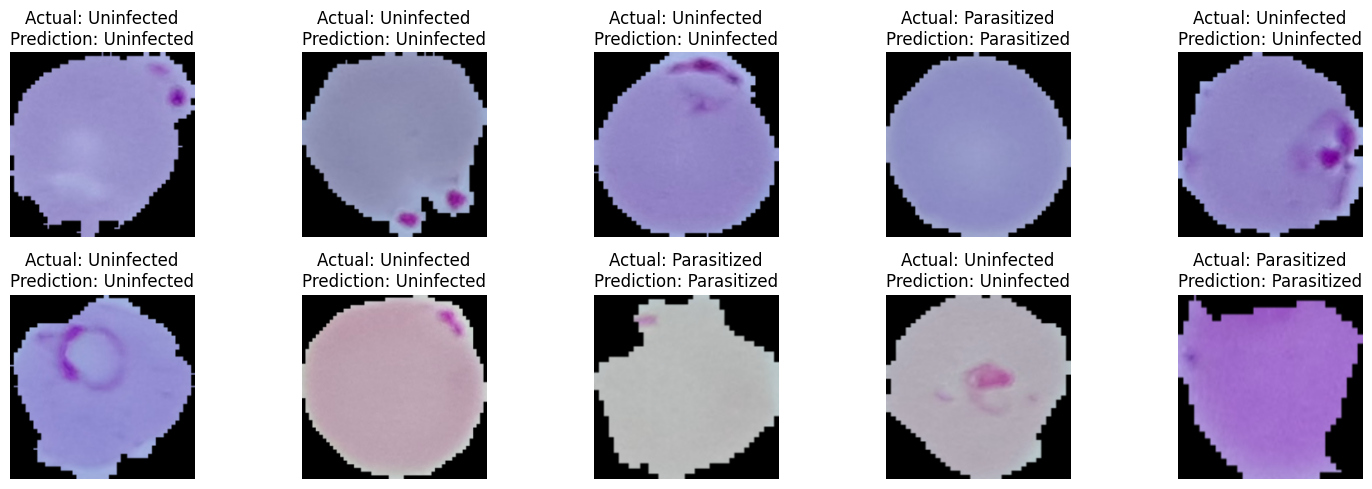

In [ ]:
# Prediction on test images (Malaria Dataset)

class_names = ['Parasitized', 'Uninfected']

num_images = 10
indices = np.random.choice(len(x_test), num_images)
images = x_test[indices]
true_labels = y_test.iloc[indices].values
predictions = np.argmax(model.predict(images), axis=1)

# Visualization
plt.figure(figsize=(15, 5))
for i in range(num_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    plt.title(f"Actual: {class_names[true_labels[i]]}\nPrediction: {class_names[predictions[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


- Early stopping was applied during training to prevent overfitting.

- While training accuracy remained consistently high, validation accuracy showed fluctuations and instability, possibly due to dataset imbalance or small batch size effects.

- The confusion matrix shows that the model performed well in distinguishing both classes, although slightly more errors were observed in the "Uninfected" class (167 misclassifications).

- The model achieved a strong performance with 96.06% test accuracy and 0.1147 test loss

## Transfer Learning - VGG16, ResNet50

### VGG16

In [ ]:
x = []
for img_path in df['img']:
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224)).astype('float32')/255.0
    x.append(img)

In [ ]:
x=np.array(x)

In [ ]:
y=df["encode_label"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2, random_state=42, stratify=y)

In [ ]:
base_model = VGG16(
    include_top=False,       # Üst katmanlar da dahil olsun
    weights='imagenet',     # Önceden eğitilmiş ağırlıkları kullan
    input_shape=(224, 224, 3)
)
base_model.trainable = False

In [95]:
model_vgg16 = Sequential([
    base_model,
    GlobalAveragePooling2D(),          # Flatten yerine GlobalAveragePooling2D
    BatchNormalization(),              # Normalizasyon katmanı ekliyoruz
    Dense(128, activation='relu'),
    Dropout(0.3),                      # Dropout 0.4 yerine 0.3 yapıldı (görseldekine uyumlu)
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')      # 2 sınıf için çıkış
])

In [96]:
model_vgg16.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [97]:
early_stopping = EarlyStopping(
    monitor='val_loss',    # Validation loss'u takip et
    patience=4,            # 4 epoch boyunca iyileşme yoksa dur
    restore_best_weights=True  # En iyi ağırlıklara geri dön
)

In [98]:
history_vgg16 = model_vgg16.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=32,
    epochs=50,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 491s 707ms/step - accuracy: 0.8189 - loss: 0.4436 - val_accuracy: 0.9291 - val_loss: 0.1884
Epoch 2/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 485s 704ms/step - accuracy: 0.9169 - loss: 0.2176 - val_accuracy: 0.9318 - val_loss: 0.1745
Epoch 3/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 483s 700ms/step - accuracy: 0.9206 - loss: 0.2061 - val_accuracy: 0.9370 - val_loss: 0.1668
Epoch 4/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 479s 695ms/step - accuracy: 0.9225 - loss: 0.2014 - val_accuracy: 0.9443 - val_loss: 0.1584
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 484s 702ms/step - accuracy: 0.9316 - loss: 0.1819 - val_accuracy: 0.9409 - val_loss: 0.1589
Epoch 6/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 485s 703ms/step - accuracy: 0.9320 - loss: 0.1811 - val_accuracy: 0.9387 - val_loss: 0.1607
Epoch 7/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 477s 693ms/step - accuracy: 0.9311 - loss: 0.1791 - val_accuracy: 0.9389 - val_loss: 0.1596
Epoch 8/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 480s 696ms/step - accuracy: 0.9379 -

In [99]:
test_loss_vgg16, test_accuracy_vgg16 = model_vgg16.evaluate(x_test, y_test, verbose=1)
print(f"VGG16 Test Loss: {test_loss_vgg16:.4f}")
print(f"VGG16 Test Accuracy: {test_accuracy_vgg16:.4f}")

173/173 ━━━━━━━━━━━━━━━━━━━━ 100s 576ms/step - accuracy: 0.9410 - loss: 0.1552
VGG16 Test Loss: 0.1547
VGG16 Test Accuracy: 0.9418


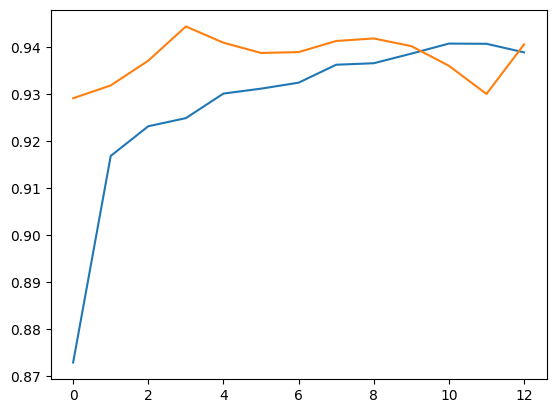

In [100]:
plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')

173/173 ━━━━━━━━━━━━━━━━━━━━ 99s 571ms/step


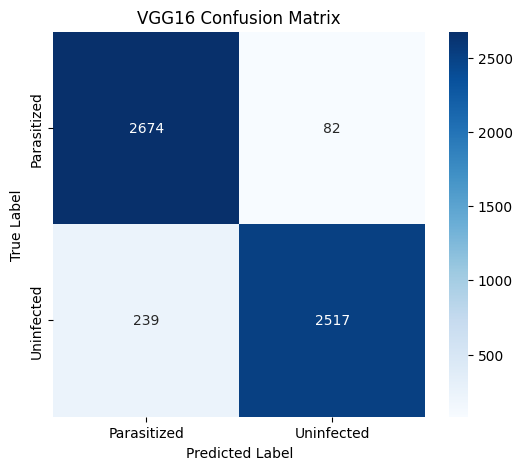

VGG16 Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.92      0.97      0.94      2756
  Uninfected       0.97      0.91      0.94      2756

    accuracy                           0.94      5512
   macro avg       0.94      0.94      0.94      5512
weighted avg       0.94      0.94      0.94      5512



In [101]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# VGG16 tahminleri
y_pred_vgg16 = model_vgg16.predict(x_test)
y_pred_classes_vgg16 = y_pred_vgg16.argmax(axis=1)

# Confusion Matrix
cm_vgg16 = confusion_matrix(y_test, y_pred_classes_vgg16)
plt.figure(figsize=(6,5))
sns.heatmap(cm_vgg16, annot=True, fmt="d", cmap="Blues", xticklabels=["Parasitized", "Uninfected"], yticklabels=["Parasitized", "Uninfected"])
plt.title('VGG16 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("VGG16 Classification Report:")
print(classification_report(y_test, y_pred_classes_vgg16, target_names=["Parasitized", "Uninfected"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


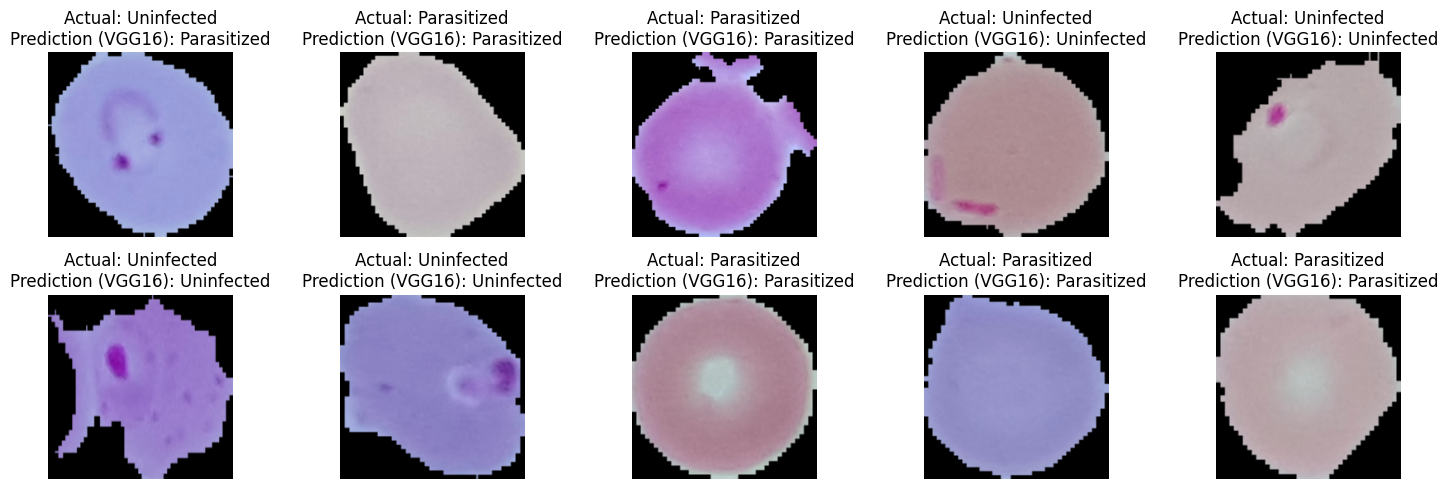

In [102]:
# Prediction on test images (Malaria Dataset) - VGG16
class_names = ['Parasitized', 'Uninfected']

num_images = 10
indices = np.random.choice(len(x_test), num_images)
images = x_test[indices]
true_labels = y_test.iloc[indices].values

# VGG16 modeli ile tahmin
predictions_vgg16 = np.argmax(model_vgg16.predict(images), axis=1)

# Visualization
plt.figure(figsize=(15, 5))
for i in range(num_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    plt.title(f"Actual: {class_names[true_labels[i]]}\nPrediction (VGG16): {class_names[predictions_vgg16[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

- Early stopping was applied with a patience of 4 to avoid overfitting, restoring the best model weights.

- Both training and validation accuracies showed a stable and consistent increase, with minimal fluctuations observed.

- The confusion matrix indicates good separation between classes, although a slightly higher number of misclassifications occurred in the "Uninfected" class (239 misclassifications).

- The model achieved a strong performance with 94.18% test accuracy and 0.1547 test loss.

### ResNet50

In [107]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

In [108]:
model_resnet50 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')      # 2 sınıf için çıkış
])

In [109]:
model_resnet50.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [111]:
history_resnet50 = model_resnet50.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=32,
    epochs=50,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 362s 525ms/step - accuracy: 0.7809 - loss: 0.4542 - val_accuracy: 0.7954 - val_loss: 0.4229
Epoch 2/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 361s 524ms/step - accuracy: 0.7877 - loss: 0.4385 - val_accuracy: 0.8099 - val_loss: 0.4079
Epoch 3/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 359s 520ms/step - accuracy: 0.7917 - loss: 0.4321 - val_accuracy: 0.7834 - val_loss: 0.4524
Epoch 4/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 359s 521ms/step - accuracy: 0.7989 - loss: 0.4223 - val_accuracy: 0.8108 - val_loss: 0.4105
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 357s 518ms/step - accuracy: 0.7957 - loss: 0.4262 - val_accuracy: 0.7964 - val_loss: 0.4253
Epoch 6/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 359s 520ms/step - accuracy: 0.8017 - loss: 0.4163 - val_accuracy: 0.8144 - val_loss: 0.4038
Epoch 7/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 358s 519ms/step - accuracy: 0.7967 - loss: 0.4174 - val_accuracy: 0.8146 - val_loss: 0.4012
Epoch 8/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 360s 523ms/step - accuracy: 0.8113 -

In [112]:
test_loss_resnet50, test_accuracy_resnet50 = model_resnet50.evaluate(x_test, y_test, verbose=1)
print(f"ResNet50 Test Loss: {test_loss_resnet50:.4f}")
print(f"ResNet50 Test Accuracy: {test_accuracy_resnet50:.4f}")

173/173 ━━━━━━━━━━━━━━━━━━━━ 75s 434ms/step - accuracy: 0.8247 - loss: 0.3812
ResNet50 Test Loss: 0.3903
ResNet50 Test Accuracy: 0.8264


173/173 ━━━━━━━━━━━━━━━━━━━━ 79s 440ms/step


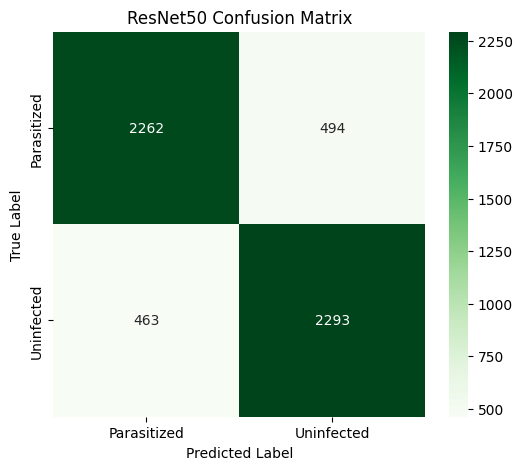

ResNet50 Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.83      0.82      0.83      2756
  Uninfected       0.82      0.83      0.83      2756

    accuracy                           0.83      5512
   macro avg       0.83      0.83      0.83      5512
weighted avg       0.83      0.83      0.83      5512



In [114]:
# ResNet50 tahminleri
y_pred_resnet50 = model_resnet50.predict(x_test)
y_pred_classes_resnet50 = y_pred_resnet50.argmax(axis=1)

# Confusion Matrix
cm_resnet50 = confusion_matrix(y_test, y_pred_classes_resnet50)
plt.figure(figsize=(6,5))
sns.heatmap(cm_resnet50, annot=True, fmt="d", cmap="Greens", xticklabels=["Parasitized", "Uninfected"], yticklabels=["Parasitized", "Uninfected"])
plt.title('ResNet50 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("ResNet50 Classification Report:")
print(classification_report(y_test, y_pred_classes_resnet50, target_names=["Parasitized", "Uninfected"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


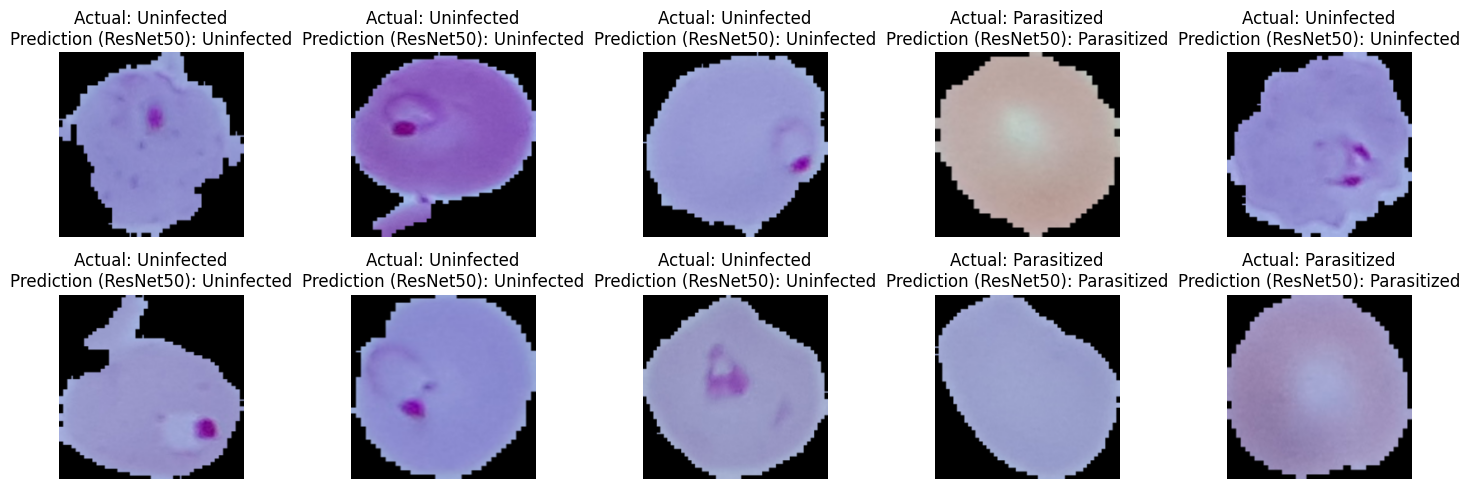

In [115]:
# Prediction on test images (Malaria Dataset) - ResNet50
class_names = ['Parasitized', 'Uninfected']

num_images = 10
indices = np.random.choice(len(x_test), num_images)
images = x_test[indices]
true_labels = y_test.iloc[indices].values

# ResNet50 modeli ile tahmin
predictions_resnet50 = np.argmax(model_resnet50.predict(images), axis=1)

# Visualization
plt.figure(figsize=(15, 5))
for i in range(num_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    plt.title(f"Actual: {class_names[true_labels[i]]}\nPrediction (ResNet50): {class_names[predictions_resnet50[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

- Early stopping was used to prevent overfitting by monitoring validation loss.

- Training and validation accuracies showed slight improvements, but there were signs of stagnation and minor overfitting after a few epochs.

- The confusion matrix shows more misclassifications compared to the other models, with both classes having higher error counts (around 460-490 misclassifications).

- The model achieved a test accuracy of 82.64% and a test loss of 0.3903, indicating a moderate performance.

## Conclusion

The CNN model achieved the highest test accuracy at 96.06% with a low test loss, but validation accuracy was a bit unstable during training. Despite small fluctuations, it showed strong generalization and only minor errors on the "Uninfected" class.

VGG16 also performed very well with 94.18% test accuracy, showing smooth and consistent validation accuracy trends. Although it had slightly more misclassifications compared to CNN, it remains a strong and reliable model.

ResNet50, on the other hand, had a significantly lower test accuracy (82.64%) and higher test loss. Training and validation accuracies improved slowly, but there were signs of stagnation and more frequent misclassifications for both classes.


The custom CNN model is the best among the three for this dataset, followed closely by VGG16. ResNet50 may require fine-tuning, better preprocessing, or a different training setup for better results.

| Feature                    | CNN (first model)   | VGG16             | ResNet50          |
|-----------------------------|---------------------|-------------------|-------------------|
| **Test Accuracy (%)**       | **96.06**            | 94.18             | 82.64             |
| **Test Loss**               | **0.1147**           | 0.1547            | 0.3903            |
| **Validation Stability**    | Fluctuating          | Stable and smooth | Mild overfitting signs |
| **Misclassification Trend** | Minor in "Uninfected" class (167 errors) | Minor in "Uninfected" class (239 errors) | Higher errors in both classes (~460 errors) |
| **Overall Comment**         | Best performance overall, small validation instability | Very good performance, slightly lower than CNN | Moderate performance, needs improvement |
